# Experimental Data Validation — WM-p (White Matter from parietal region)

This notebook applies the two-stage physics-informed GPR framework to experimental brain tissue data (White Matter from perietal region — WM–p) digitized from the literature. Unlike synthetic data case, the material response is assumed incompressible (J = 1), and thus the stress decomposition no longer involves an independently modeled volumetric response function. Consequently, the Stage I training procedure is modified to only consider the isochoric response functions (details in the manuscript).

Overall, the notebook includes:
- loading and preprocessing of experimental uniaxial stress–stretch data,
- Stage I learning of the undamaged hyperelastic response,
- Stage II learning of the damage response,
- model validation and analysis of results.

For exact reproduction of the manuscript results, run this notebook using the Python 3.13 environment specified in `requirements_paper.txt`, and execute all cells using **Kernel → Restart & Run All**.

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import scipy.optimize
from scipy.spatial.distance import cdist
from scipy.interpolate import interp1d, CubicSpline
from scipy.integrate import simpson, trapezoid, quad
from mpl_toolkits.axes_grid1 import Divider, Size
from itertools import combinations, permutations, product
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn import preprocessing
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic,
                                                  ExpSineSquared, DotProduct,
                                                  ConstantKernel, WhiteKernel)
from typing import Optional

In [2]:
# Environment check for reproducibility
import scipy
import sklearn
import pandas as pd
import matplotlib

print("Python executable:", sys.executable)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

Python executable: C:\Users\kshit\AppData\Local\Programs\Python\Python313\python.exe
numpy: 2.3.2
scipy: 1.16.1
scikit-learn: 1.7.1
pandas: 2.3.3
matplotlib: 3.10.6


In [3]:
sys.path.append(os.path.abspath(".."))

from src.experimental_kinematics import (
    right_cauchy_green,
    invariants,
    ref_deviatoric
)

from src.experimental_constitutive import (
    hyperelastic_coefficients,
    damage_coefficients,
    strain_energy_density,
    energy_spline_adaptive,
    energy_gauss_per_interval
)

from src.constrained_gpr import (
    matern52_kernel,
    matern52_kernel_dx,
    matern52_kernel_dxdx,
    neg_log_marginal_likelihood,
    nonnegativity_constraint,
    derivative_constraint,
    penalized_obj,
    predict_mu,
    predict_var
)

## 1. Experimental data loading and preprocessing

This section loads the digitized stress–stretch data for WM-p and prepares it for data-driven constitutive modeling.

In [4]:
# Getting the training data from .data\ folder.

data = pd.read_csv('../data/brain_wm_p.csv') # Details: White Matter_parietal lobe_13mm-8mm prismatic_frontal dir

data = data.to_numpy()
stretch_raw = data[:,0]
stress_raw = data[:,1] # Nominal stress (1st PK).

N = 101
F11_train = np.linspace(np.min(stretch_raw),np.max(stretch_raw), N)
interp_data = interp1d(stretch_raw,stress_raw)
S11_training = interp_data(F11_train)/F11_train # Divide by stretch to get the 2nd PK stress.

F_training = []

for i in range(N):
    F_training.append(np.array([F11_train[i], 0, 0, 0, (1/np.sqrt(F11_train[i])), 0, 0, 0, (1/np.sqrt(F11_train[i]))]))

I1_training, I2_training, J_training = invariants(F_training)
C_training, C_bar_training = right_cauchy_green(F_training)

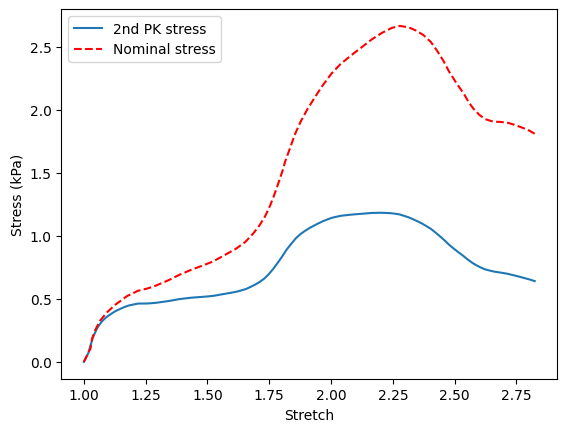

In [5]:
# Plotting the training data: Raw nominal stress-stretch and processed 2nd Piola-Kirchhoff S11 vs F11 data.
plt.plot(F11_train, S11_training, label = '2nd PK stress')
plt.plot(stretch_raw, stress_raw,'r--', label = 'Nominal stress')
plt.legend()
plt.ylabel('Stress (kPa)')
plt.xlabel('Stretch')
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\3559602990.py:28: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


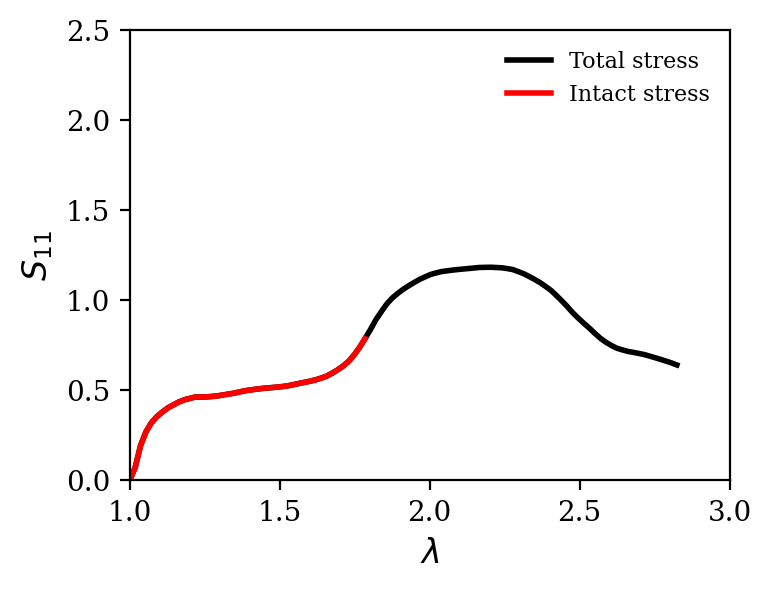

In [6]:
# Visualizing total vs intact stress response. 

intact_cutoff = (np.max(F11_train)+1)/2 - 0.11

plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

plt.xlim([1, 3])
plt.ylim([0, 2.5])

ax.plot(F11_train, S11_training, c = 'k', linewidth = 2, label = "Total stress") #marker = 'o', markersize = '5', 
id = np.where(F11_train<=intact_cutoff)
ax.plot(F11_train[id], S11_training[id], c = 'r', linewidth = 2, label = "Intact stress") # Up to half the peak stretch

ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{11}$')
ax.legend(frameon=False, prop={'size': 8})

plt.show()

## 2. Stage I: learning the undamaged hyperelastic response

This section fits the Stage I GPR model using the experimental data corresponding to the undamaged response.

In [7]:
# Generating input data for Stage I GPR model: Hyperelastic regime (no damage)
N_h = np.shape(id)[1]

input_training_GPR_iso_h = np.vstack((np.array(I1_training), np.array(I2_training))).T # This will be used later to train the single stage GPR model.

F_h_training = []

for i in range(N_h):
    F_h_training.append(F_training[i])
    
I1_h_training, I2_h_training, J_h_training = invariants(F_h_training)
C_h_training, C_h_bar_training = right_cauchy_green(F_h_training)
input_h_training_GPR_iso_h = np.vstack((np.array(I1_h_training), np.array(I2_h_training))).T

In [8]:
# Generating stress tensors for training the Stage I GPR model.

S_training = []

for i in range(len(F_training)):
    S_training.append(np.array([[S11_training[i], 0., 0.], [0., 0., 0.], [0., 0., 0.]]))

In [9]:
# Now generating output training data for the Stage I GPR model.

# Hyperelastic stress in the undamaged material (assumed to be up to half of the peak stretch).
S_h_training = []

for i in range(N_h):
    S_h_training.append(S_training[i])

gamma1_h, gamma2_h = hyperelastic_coefficients(C_h_training, S_h_training)
output_h_training_GPR_iso_h = np.vstack((gamma1_h, gamma2_h)).T

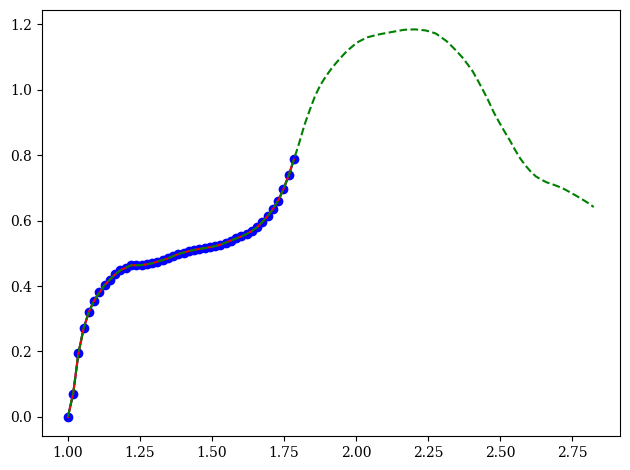

In [10]:
# Testing the accuracy of the generation of outputs (i.e., gamma1 and gamma2) 
S11_h_training, S22_h_training = [], []
for i in range(len(S_h_training)):
    S11_h_training.append(S_h_training[i][0,0])
    S22_h_training.append(S_h_training[i][1,1])

# The recreated response from the generated gamma 1, gamma 2 training data.
S_h_total_rec = []
S_h_total_rec_V2 = []

S11_h_total_rec, S22_h_total_rec = [], []
S11_h_total_rec_V2, S22_h_total_rec_V2 = [], []

for i in range(len(F_h_training)):
    G1_temp = np.linalg.inv(C_h_training[i])
    G2_temp = ref_deviatoric(np.eye(3), C_h_training[i])
    G3_temp = ref_deviatoric(C_h_bar_training[i], C_h_training[i])
    
    S_h_total_rec.append((gamma1_h[i] * (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)) +
                        (gamma2_h[i] * (G3_temp - (G3_temp[1][1]/G1_temp[1][1]) * G1_temp)))
    
    # Alternative way to compute stress, just for validation.
    S_h_total_rec_V2.append((gamma1_h[i] * (G2_temp - ((1/3) * (1/F11_train[i] - F11_train[i]**2)) * G1_temp)) +
                        (gamma2_h[i] * (G3_temp - ((1/3) * (1/(F11_train[i]**2) - F11_train[i]**4)) * G1_temp)))
    
for i in range(len(S_h_total_rec)):
    S11_h_total_rec.append(S_h_total_rec[i][0,0])
    S22_h_total_rec.append(S_h_total_rec[i][1,1])
    S11_h_total_rec_V2.append(S_h_total_rec_V2[i][0,0])
    S22_h_total_rec_V2.append(S_h_total_rec_V2[i][1,1])

plt.plot(F11_train[:N_h], S11_h_training, color = 'b', marker = 'o')
plt.plot(F11_train[:N_h], S11_h_total_rec, color = 'r')
plt.plot(F11_train, S11_training, color = 'g', linestyle = '--')

In [11]:
# Printing the difference between stresses calculated using the formula based on Gs (integrity basis) vs those
# calculated using lambda. The ideal value should be zero.
diff_S11 = np.array(S11_h_total_rec) - np.array(S11_h_total_rec_V2)
diff_S22 = np.array(S22_h_total_rec) - np.array(S22_h_total_rec_V2)
np.max(diff_S11), np.max(diff_S22)

(np.float64(1.6653345369377348e-16), np.float64(3.638517181136755e-16))

In [12]:
# Numerically computing the total strain energy density function (vol + iso,h) and comparing with the analytical
# values.
W_h_numerical = strain_energy_density(C_h_training, S_h_training) # Numerically obtained strain energy density.
psi_numerical = strain_energy_density(C_training, S_training) # Modified energy density (shows asymptotic behavior)

In [13]:
# Defining the GPR kernels.
kernels = [ConstantKernel(1.0, (1e-4, 1e4)) * RBF(1, (1e-6, 1e6)),
           1.0 * RationalQuadratic(length_scale=1.0, alpha=0.1),
           1.0 * ExpSineSquared(length_scale=1.0, periodicity=1,
                                length_scale_bounds=(1.0e-5, 100.0),
                                periodicity_bounds=(1.0, 10.0)),
           ConstantKernel(0.1, (0.01, 10.0))
           * (DotProduct(sigma_0=1.0, sigma_0_bounds=(0.0, 10.0)) ** 2),
           1.0 * Matern(length_scale=1.0, nu=1.5),
          1.0 * Matern(length_scale=1.0, nu=2.5),
          ConstantKernel(1.0, (1e0, 1e4)) * RBF(1, (1e0, 1e6))]


In [14]:
# Building the GPR model.

Krig_2_iso_h = GaussianProcessRegressor(kernel=kernels[5], alpha=5e-1, n_restarts_optimizer=20, normalize_y=True)

Krig_2_iso_h.fit(input_h_training_GPR_iso_h,output_h_training_GPR_iso_h)
Krig_2_iso_h.score(input_h_training_GPR_iso_h,output_h_training_GPR_iso_h)

0.6430945175873598

## 3. Training data generation for Stage II
This section generates the intact strain energy density and stress-reduction factor data used to build the Stage II model.

In [15]:
# Generating the training data for the Stage II GPR model to capture progressive damage.

# Predicted isochoric hyperelastic stress over the entire loading regime (hyperelastic + damage).

S_h_GPRpred = []
for i in range(N):
    G1_temp = np.linalg.inv(C_training[i])
    G2_temp = ref_deviatoric(np.eye(3), C_training[i])
    G3_temp = ref_deviatoric(C_bar_training[i], C_training[i])
    
    S_h_GPRpred.append((Krig_2_iso_h.predict(input_training_GPR_iso_h)[i,0] * (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)) +
                        (Krig_2_iso_h.predict(input_training_GPR_iso_h)[i,1] * (G3_temp - (G3_temp[1][1]/G1_temp[1][1]) * G1_temp)))
    

W_h_GPRpred = strain_energy_density(C_training, S_h_GPRpred)

input_training_GPR3 = np.array(W_h_GPRpred).reshape(-1,1)

xi = damage_coefficients(S_h_GPRpred, S_training)

xi[0] = 1 # Damage coefficient at the reference state must be unity.

output_training_GPR3 = xi

In [16]:
# Comparing GPR-predicted and training stresses.
S11_h_GPRpred, S22_h_GPRpred = [], []

for i in range(N):
    S11_h_GPRpred.append(S_h_GPRpred[i][0,0])
    S22_h_GPRpred.append(S_h_GPRpred[i][1,1])

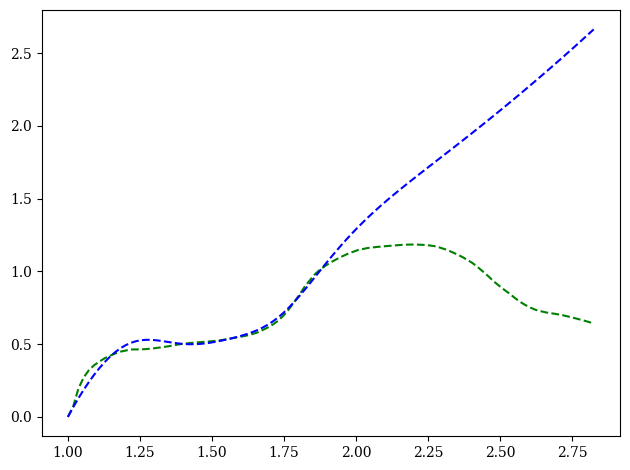

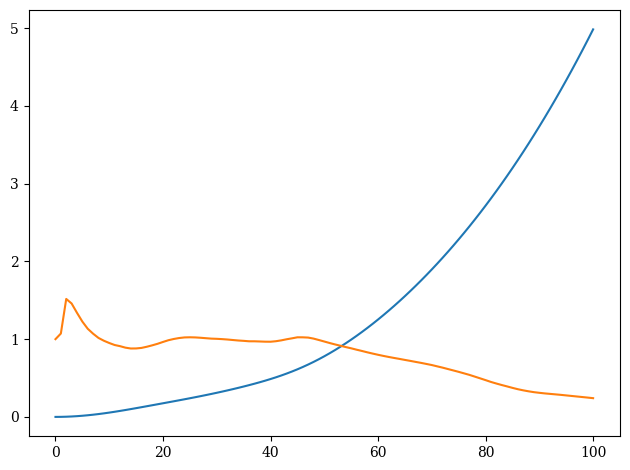

In [17]:
plt.plot(F11_train, S11_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S11_h_GPRpred, color = 'b', linestyle = '--')
plt.show()

plt.plot(input_training_GPR3)
plt.plot(output_training_GPR3)
plt.show()

In [18]:
# Creating new input-output datapoints at large energy values that correspond to Xi of zero.
input_training_GPR3[-1]
linear_extrapolate = interp1d(np.arange(input_training_GPR3.shape[0]), np.squeeze(input_training_GPR3), fill_value="extrapolate")
x_extended = np.linspace(np.arange(input_training_GPR3.shape[0])[-1], np.arange(input_training_GPR3.shape[0])[-1] + (N-1),N)
input_constrained_GPR3_pos = linear_extrapolate(x_extended).reshape(-1,1)[int(0.20*(N-1)):]
output_constrained_GPR3_pos = np.zeros(input_constrained_GPR3_pos.shape)

# Combine the generated complete damage (Xi = 0) data with the original training data
input_training_GPR3_ext = np.vstack((input_training_GPR3, input_constrained_GPR3_pos))
output_training_GPR3_ext = np.vstack((output_training_GPR3, output_constrained_GPR3_pos))

## 4. Stage II: learning the damage response

This section constructs standard (only for comparison) and constrained GPR models to capture the damage evolution behavior from the experimental data.

In [19]:
# Building two alternative GPR models for comparison: one standard GPR model between W and Xi (with extended data
# incorporating zero Xi at large W values); and one constrained GPR model that enforces monotonicity and
# non-negativity constraint on Xi in addition to the Xi = 0 data at large W values that enforces complete failure.

# Constraint data points generation.
x_cons = np.linspace(6,15, 30).reshape(-1,1)

# Testing data points generation (for evalutation of the trained model).
x_test = np.linspace(input_training_GPR3_ext[0],input_training_GPR3_ext[-1],500)

x0 = np.log([1.0, 1.0])  # Initial value of Kernel hyperparameters. Note: We use log parameters to feed into x0,
# which are then shifted back to the original parameters in NLML and constraint functions. In this way, it is not
# the actual parameters but the log of parameters that are resulted by the optimizer. This ensures parameters
# always stay positive during the optimization process, important for numerical stability.
noise = 0.25e-2

# === Standard GPR Optimization ===
res_std = scipy.optimize.minimize(
    neg_log_marginal_likelihood,
    x0,
    args=(input_training_GPR3_ext, output_training_GPR3_ext, noise),
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 1000}
)
lengthscale_std, variance_std = np.exp(res_std.x)
mu_std = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_std, variance_std, noise)

# === Constrained GPR Optimization using a Penalized positivity NLML (for tighter, less-smooth fits) ===
cons = [
    {'type': 'ineq', 'fun': lambda p: nonnegativity_constraint(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons, noise)},
    {'type': 'ineq', 'fun': lambda p: derivative_constraint(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons, noise)}
]

# Define how strictly constraints are enforced via the penalty term (lam).
lam = 1e3         # penalty strength

res_pen = scipy.optimize.minimize(
    lambda p: penalized_obj(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons, lam, noise),
    res_std.x,
    method='L-BFGS-B',
    options={'maxiter': 2000}
)
lengthscale_pen, variance_pen = np.exp(res_pen.x)
mu_pen = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_pen, variance_pen, noise)

# An alternative method: Constrained hyperparameter optimization with SLSQP or COBYLA.
res_cons2 = scipy.optimize.minimize(
    neg_log_marginal_likelihood,
    x0,
    args=(input_training_GPR3_ext, output_training_GPR3_ext, noise),
    constraints=cons,
    method='COBYLA',
    options={'disp': False, 'maxiter': 1000} # Turn "disp" to True to see detailed convergence messages and results.
)

lengthscale_cons2, variance_cons2 = np.exp(res_cons2.x)
mu_cons2 = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_cons2, variance_cons2, noise)

C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\100966630.py:18: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res_std = scipy.optimize.minimize(


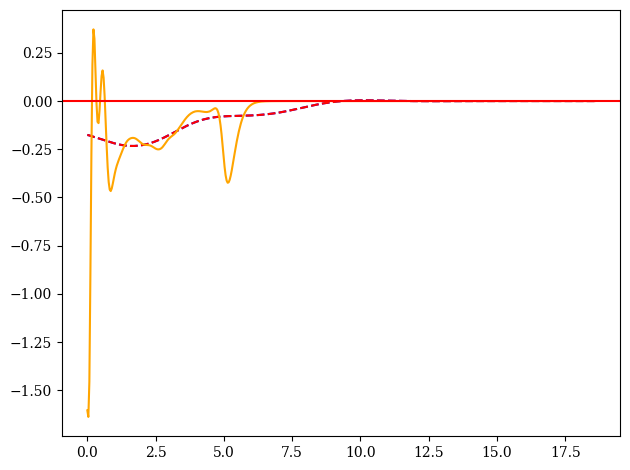

In [20]:
# Computing the derivatives of the posteriors to check monotonicity in the three GPRs.
derivative_std = np.gradient(mu_std.flatten(),x_test.flatten())
derivative_pen = np.gradient(mu_pen.flatten(),x_test.flatten())
derivative_cons2 = np.gradient(mu_cons2.flatten(),x_test.flatten())

plt.plot(x_test, derivative_std, 'b--')
plt.plot(x_test, derivative_pen, 'r--')
plt.plot(x_test, derivative_cons2, 'orange')
plt.axhline(y=0, color='r', linestyle='-')

## 5. Model validation and comparison

This section evaluates the trained model under tensile and compressive uniaxial loading and compares predictions against the experimental dataset in the training regime.

In [21]:
# Generating data for testing. Here, it is important to ensure that the training data remains intact inside the
# testing set, and compression data is added while ensuring the same spacing as the tension regime.

F11_comp = 2-F11_train
F11_comp_ = F11_comp[:np.where(F11_comp>0.5)[-1][-1] + 1] # Only up to a minimum of 0.5 stretch.
F11 = np.concatenate((np.flip(F11_comp_)[:-1], F11_train))

In [22]:
# Testing the accuracy of the trained GPR model.
import time

F_test = []
N = np.shape(F11)[0]

for i in range(N):
    F_test.append(np.array([F11[i], 0, 0, 0, 1/np.sqrt(F11[i]), 0, 0, 0, 1/np.sqrt(F11[i])]))
    
I1_test, I2_test, _ = invariants(F_test)
C_test, C_bar_test = right_cauchy_green(F_test)
input_test_iso_h = np.vstack((np.array(I1_test), np.array(I2_test))).T

# Stage I GPR model
output_h_test_iso_h = Krig_2_iso_h.predict(input_test_iso_h)

S_h_test = []
for i in range(len(F_test)):
    G1_temp = np.linalg.inv(C_test[i])
    G2_temp = ref_deviatoric(np.eye(3), C_test[i])
    G3_temp = ref_deviatoric(C_bar_test[i], C_test[i])
    
    S_h_test.append((output_h_test_iso_h[i,0] * (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)) +
                        (output_h_test_iso_h[i,1] * (G3_temp - (G3_temp[1][1]/G1_temp[1][1]) * G1_temp)))

S11_h_test, S22_h_test = [], []
for i in range(len(F_test)):
    S11_h_test.append(S_h_test[i][0,0])
    S22_h_test.append(S_h_test[i][1,1])
    
# Compute the strain energy density. This needs to be done separately for tension and compression.
W_h_ten_temp = strain_energy_density(C_test[int(np.where(F11==1.0)[0][0]):], S_h_test[int(np.where(F11==1.0)[0][0]):])
W_h_comp_temp = strain_energy_density(list(reversed(C_test[:int(np.where(F11==1.0)[0][0])+1])), list(reversed(S_h_test[:int(np.where(F11==1.0)[0][0])+1])))
W_h_test = list(reversed(W_h_comp_temp)) + W_h_ten_temp[1:]

In [23]:
# Stage II GPR model with monotonicity and non-negativity constraints.
input_test_GPR3 = np.array(W_h_test).reshape(-1,1)

output_test = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3, lengthscale_pen, variance_pen, noise)

S_test = []
for i in range(len(F_test)):
    S_test.append(output_test[i] * S_h_test[i])
    
S11_test, S22_test = [], []
for i in range(len(F_test)):
    S11_test.append(S_test[i][0,0])
    S22_test.append(S_test[i][1,1])

In [24]:
# Compute total strain energy density from the fully trained model. This needs to be done separately for tension and compression.
W_h_ten_temp = strain_energy_density(C_test[int(np.where(F11==1.0)[0][0]):], S_h_test[int(np.where(F11==1.0)[0][0]):])
W_h_comp_temp = strain_energy_density(list(reversed(C_test[:int(np.where(F11==1.0)[0][0])+1])), list(reversed(S_h_test[:int(np.where(F11==1.0)[0][0])+1])))

W_ten_test = strain_energy_density(C_test[int(np.where(F11==1.0)[0][0]):], S_test[int(np.where(F11==1.0)[0][0]):])
W_comp_test = strain_energy_density(list(reversed(C_test[:int(np.where(F11==1.0)[0][0])+1])), list(reversed(S_test[:int(np.where(F11==1.0)[0][0])+1])))
W_test = list(reversed(W_comp_test)) + W_ten_test[1:]

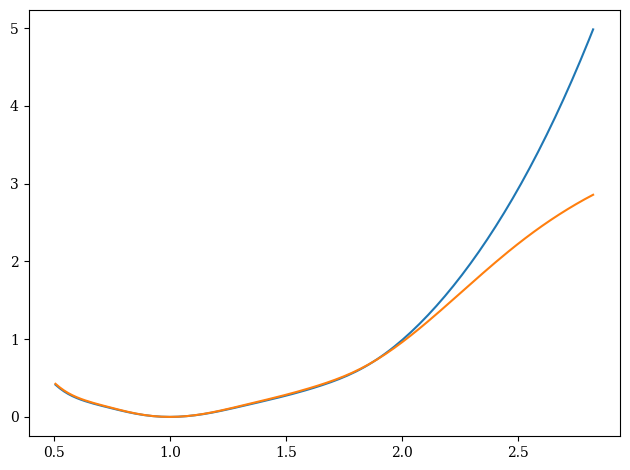

In [25]:
# Compare intact vs total strain energy density.
plt.plot(F11,W_h_test)
plt.plot(F11, W_test)
plt.show()

## 6. Error analysis and manuscript figures

This section computes error metrics and generates the figures used in the manuscript.

In [26]:
# Computing the fitting error. Only the 11-component is considered as all others are zero.
S11_test_tension = S11_test[int(np.where(F11==1.0)[0][0]):]

err_test_overall = []
for i in range(len(S_training)):
    S_diff = S11_test_tension[i] - S11_training[i]
    # Avoiding division by very small values by adding a max condition in the denominator.
    err_test_overall.append(np.linalg.norm(S_diff) / np.max((0.01*np.max(S11_training), S11_training[i])))

mean_err_trainregime = np.nanmean(np.array(err_test_overall)) # mean error in the training regime.
max_err_trainregime = np.nanmax(np.array(err_test_overall))

print('Mean relative errors in the training regime:', mean_err_trainregime)
print('Max relative error of the GPR surrogate model:', max_err_trainregime)

Mean relative errors in the training regime: 0.05106924329947746
Max relative error of the GPR surrogate model: 0.297663343725043


<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\460384786.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


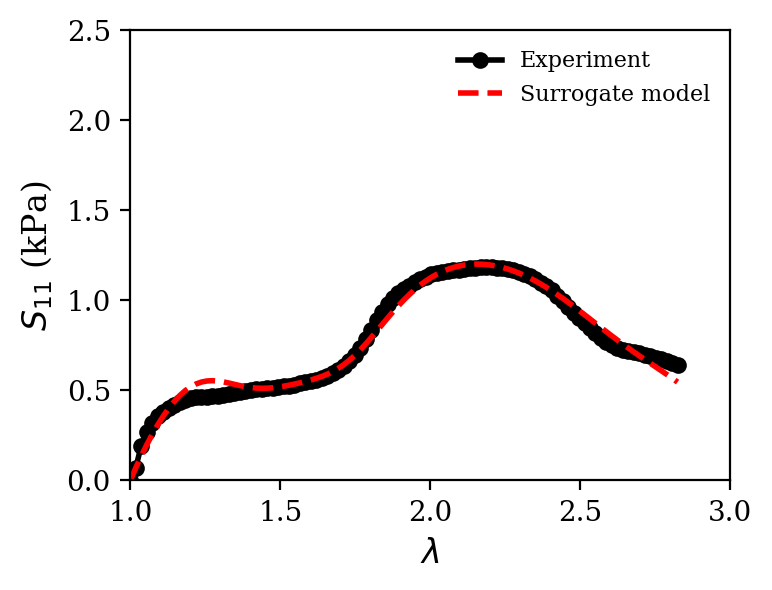

In [27]:
# Plotting the fitted stress by the data-driven model.
# Plot 8c. Training data and Fitted Response.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(F11_train, S11_training, c = 'k', marker = 'o', markersize = '5', linewidth = 2, label = 'Experiment')
ax.plot(F11[int(np.where(F11==1.0)[0][0]):], np.array(S11_test)[int(np.where(F11==1.0)[0][0]):], c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model')
plt.xlim([1, 3])
plt.ylim((0, 2.5))

ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{11}$ (kPa)')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Hyperelastic_training_fitting_WM-p.svg")
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\907771563.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


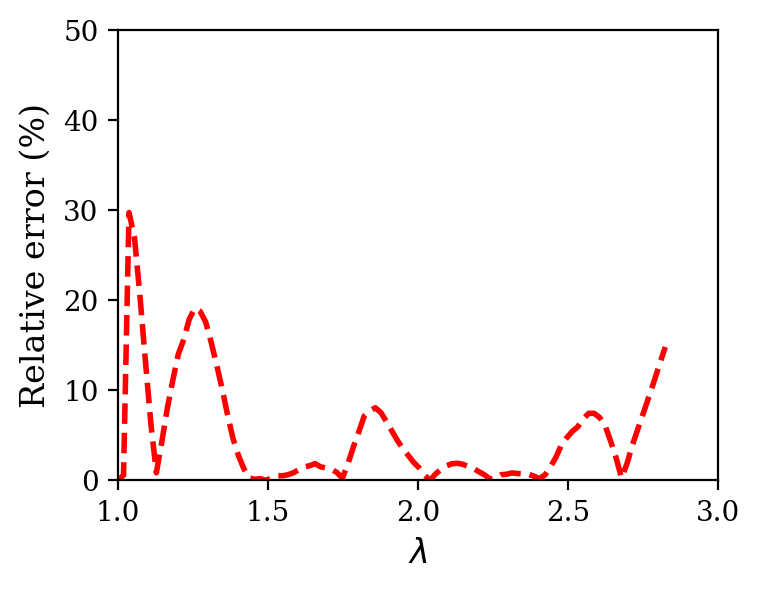

In [28]:
# Plot 8f: Relative error metric versus (lambda stretch) in the fitting regime

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

plt.xlim([1, 3])
plt.ylim([0, 50])

ax.plot(F11_train, 100 * np.array(err_test_overall), c = 'r', linestyle = '--', linewidth = 2)
ax.set_xlabel('$\lambda$')
ax.set_ylabel('Relative error (%)')
plt.savefig("../results/Hyperelastic_training_fitting_error_WM-p.svg",bbox_inches='tight')
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\c'
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\1712458748.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\1712458748.py:24: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('$\chi$')
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\1712458748.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, prop={'size': 8})


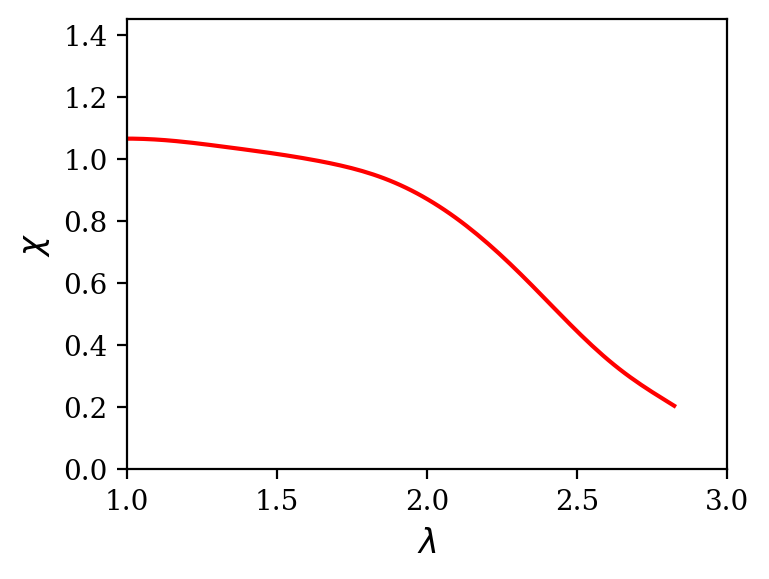

In [29]:
# Plot 8i: Predicted stress-reduction factor (output of Stage II) vs stretch.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(F11, output_test, c = 'r', linestyle = '-')

plt.ylim((0, 1.45))
plt.xlim((1, 3))

ax.set_xlabel('$\lambda$')
ax.set_ylabel('$\chi$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Xi_vs_stretch_WM-p.svg")
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\p'
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\1504814021.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\1504814021.py:27: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel('$\psi$ (kPa)')
C:\Users\kshit\AppData\Local\Temp\ipykernel_16272\1504814021.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, prop={'size': 8})


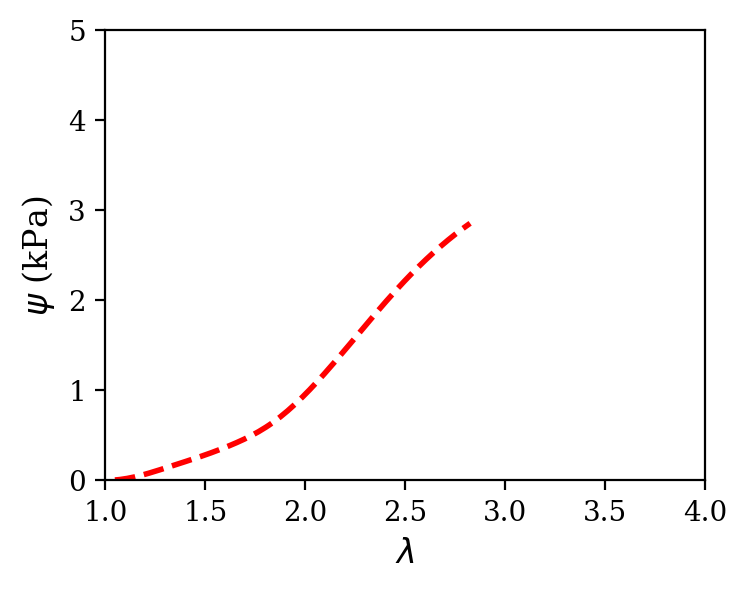

In [30]:
# Plot: Strain energy density predictions of stage I vs stage II.
# Note that Fig. 9 in the manuscript was created by predicting material response up to lambda = 3.5. This allows
# visualization of saturation/failure energy.

plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(F11, np.array(W_test), c = 'r', linestyle = '--', linewidth = 2)#, label = 'Total strain energy density prediction (Stages I and II)')

plt.ylim((0, 5))
plt.xlim((1, 4))

ax.set_xlabel('$\lambda$')
ax.set_ylabel('$\psi$ (kPa)')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Total_strain_energy_density_WM-p.svg")
plt.show()